# Caso 01 — IA e ciência de dados na saúde

Comparativo de **Decision Tree**, **Naive Bayes (Gaussian)** e **KNN** no dataset Pima Indians Diabetes, com foco em minimizar falsos negativos (Recall).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

DATA_PATH = Path("diabetes.csv")
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 10

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(df.head(3))
print("\nDistribuição de Outcome:")
print(df["Outcome"].value_counts(normalize=True).rename("proporção").round(3))

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  

Distribuição de Outcome:
Outcome
0    0.651
1    0.349
Name: proporção, dtype: float64


## Preparação dos dados

No Pima, zeros em Glucose, BloodPressure, SkinThickness, Insulin e BMI são tratados como **missing** (não como valor clínico). A imputação e o Min-Max entram em `Pipeline` para evitar vazamento no CV.

In [2]:
ZERO_AS_MISSING = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]


def make_prep(scale: bool) -> Pipeline:
    """Cria um preprocessor novo (evita compartilhar estado entre modelos)."""
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", MinMaxScaler()))
    return Pipeline(steps)


df_clean = df.copy()
df_clean[ZERO_AS_MISSING] = df_clean[ZERO_AS_MISSING].replace(0, np.nan)

print("Missing após troca de zeros inválidos:")
print(df_clean[ZERO_AS_MISSING].isna().sum())

X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

models = {
    # criterion explícito; max_depth = pré-poda (regularização)
    "Decision Tree (pré-poda)": Pipeline(
        [
            ("prep", make_prep(scale=False)),
            (
                "clf",
                DecisionTreeClassifier(
                    criterion="gini",
                    max_depth=5,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    # pós-poda via cost-complexity pruning
    "Decision Tree (pós-poda)": Pipeline(
        [
            ("prep", make_prep(scale=False)),
            (
                "clf",
                DecisionTreeClassifier(
                    criterion="gini",
                    ccp_alpha=0.01,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Naive Bayes": Pipeline(
        [
            ("prep", make_prep(scale=False)),
            ("clf", GaussianNB()),
        ]
    ),
    "KNN": Pipeline(
        [
            ("prep", make_prep(scale=True)),
            (
                "clf",
                KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
            ),
        ]
    ),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc",
    "accuracy": "accuracy",
}

print("Pipelines prontos:", list(models.keys()))

Missing após troca de zeros inválidos:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Pipelines prontos: ['Decision Tree (pré-poda)', 'Decision Tree (pós-poda)', 'Naive Bayes', 'KNN']


## Validação cruzada estratificada (K=10)

Média ± desvio padrão por métrica. Seleção do melhor modelo pelo **Recall** (custo de falso negativo).

In [3]:
results_cv = {}
rows = []

print(f"--- Stratified K-Fold (K={N_SPLITS}) ---\n")
for name, model in models.items():
    cv_results = cross_validate(
        model, X, y, cv=cv, scoring=scoring, n_jobs=-1
    )
    summary = {}
    for metric in scoring:
        scores = cv_results[f"test_{metric}"]
        summary[metric] = (scores.mean(), scores.std())
        rows.append(
            {
                "modelo": name,
                "métrica": metric,
                "média": scores.mean(),
                "std": scores.std(),
            }
        )
    results_cv[name] = summary
    print(name)
    for metric, (mean, std) in summary.items():
        print(f"  {metric:10s}: {mean:.4f} ± {std:.4f}")
    print()

cv_table = pd.DataFrame(rows)
cv_pivot = cv_table.pivot(index="modelo", columns="métrica", values="média").round(4)
display(cv_pivot)

best_model_name = max(results_cv, key=lambda k: results_cv[k]["recall"][0])
print(f"Melhor modelo por Recall (CV): {best_model_name}")
print(
    f"Recall CV = {results_cv[best_model_name]['recall'][0]:.4f} "
    f"± {results_cv[best_model_name]['recall'][1]:.4f}"
)

--- Stratified K-Fold (K=10) ---



Decision Tree (pré-poda)
  precision : 0.6752 ± 0.1055
  recall    : 0.6373 ± 0.1447
  f1        : 0.6431 ± 0.0928
  auc       : 0.7864 ± 0.0701
  accuracy  : 0.7589 ± 0.0561



Decision Tree (pós-poda)
  precision : 0.6551 ± 0.1104
  recall    : 0.6608 ± 0.1749
  f1        : 0.6336 ± 0.0928
  auc       : 0.7931 ± 0.0587
  accuracy  : 0.7419 ± 0.0601

Naive Bayes
  precision : 0.6610 ± 0.1222
  recall    : 0.6010 ± 0.1084
  f1        : 0.6222 ± 0.0878
  auc       : 0.8128 ± 0.0571
  accuracy  : 0.7460 ± 0.0605

KNN
  precision : 0.6541 ± 0.1039
  recall    : 0.6115 ± 0.0900
  f1        : 0.6309 ± 0.0918
  auc       : 0.7940 ± 0.0621
  accuracy  : 0.7499 ± 0.0638



métrica,accuracy,auc,f1,precision,recall
modelo,,,,,
Decision Tree (pré-poda),0.7589,0.7864,0.6431,0.6752,0.6373
Decision Tree (pós-poda),0.7419,0.7931,0.6336,0.6551,0.6608
KNN,0.7499,0.7940,0.6309,0.6541,0.6115
Naive Bayes,0.7460,0.8128,0.6222,0.6610,0.6010


Melhor modelo por Recall (CV): Decision Tree (pós-poda)
Recall CV = 0.6608 ± 0.1749


## Sensibilidade do KNN (K e métrica de distância)

Grid leve sobre `n_neighbors` e `metric` (euclidiana vs manhattan), ainda com Stratified K-Fold e Pipeline (imputer + Min-Max).

In [4]:
knn_pipe = Pipeline(
    [
        ("prep", make_prep(scale=True)),
        ("clf", KNeighborsClassifier()),
    ]
)

param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9, 11],
    "clf__metric": ["euclidean", "manhattan"],
}

knn_search = GridSearchCV(
    knn_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)
knn_search.fit(X, y)

knn_grid = (
    pd.DataFrame(knn_search.cv_results_)[
        [
            "param_clf__n_neighbors",
            "param_clf__metric",
            "mean_test_score",
            "std_test_score",
        ]
    ]
    .rename(
        columns={
            "param_clf__n_neighbors": "K",
            "param_clf__metric": "métrica",
            "mean_test_score": "recall_médio",
            "std_test_score": "recall_std",
        }
    )
    .sort_values("recall_médio", ascending=False)
)

print("Melhores configs KNN (ordenadas por Recall CV):")
display(knn_grid.head(10).round(4))
print("Melhor KNN:", knn_search.best_params_, f"| Recall={knn_search.best_score_:.4f}")

Melhores configs KNN (ordenadas por Recall CV):


,K,métrica,recall_médio,recall_std
3,9,euclidean,0.6158,0.0846
7,7,manhattan,0.6154,0.0935
8,9,manhattan,0.6152,0.1057
1,5,euclidean,0.6115,0.0900
0,3,euclidean,0.6113,0.1153
2,7,euclidean,0.6044,0.0835
4,11,euclidean,0.5933,0.0976
9,11,manhattan,0.5895,0.0756
6,5,manhattan,0.5778,0.1074
5,3,manhattan,0.5513,0.1191


Melhor KNN: {'clf__metric': 'euclidean', 'clf__n_neighbors': 9} | Recall=0.6158


## Holdout estratificado (70/30) — ROC e matriz de confusão

Usado só para visualização e métricas finais do melhor modelo do CV. O scaler/imputer continua dentro do Pipeline (fit apenas no treino).

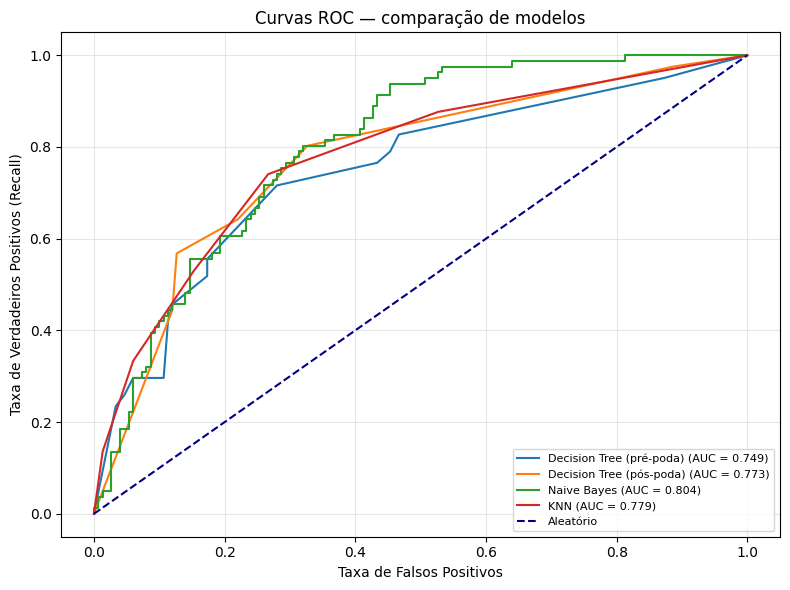

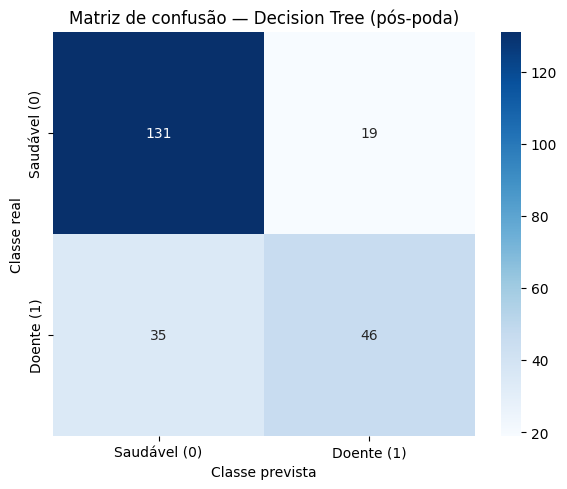

--- Métricas no teste (30%) — Decision Tree (pós-poda) ---
Precision: 0.7077
Recall:    0.5679
F1-Score:  0.6301
Accuracy:  0.7662

Matriz de confusão:
[[131  19]
 [ 35  46]]
Figuras salvas em: C:\Users\jesus\OneDrive\Documentos\GitHub\TrabalhoPos\trabalho 2\figuras


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

plt.figure(figsize=(8, 6))
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="navy", label="Aleatório")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curvas ROC — comparação de modelos")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curve.png", dpi=150)
plt.show()

best_model = fitted[best_model_name]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Saudável (0)", "Doente (1)"],
    yticklabels=["Saudável (0)", "Doente (1)"],
)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title(f"Matriz de confusão — {best_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print(f"--- Métricas no teste (30%) — {best_model_name} ---")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"\nMatriz de confusão:\n{cm}")
print(f"Figuras salvas em: {FIG_DIR.resolve()}")